**Importing libraries**

In [2]:
# Importing all required libraries for data handling, visualization and modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [3]:
# Importing machine learning libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve
)
import lightgbm as lgb



**Loading Dataset**

In [4]:
df = pd.read_csv('PS2_DATASET.csv')
df

,order_id,user_id,restaurant_id,city,item_id,budget_type,order_frequency,cuisine,price_range,category,...,has_drink,has_dessert,has_starter,user_total_orders,user_avg_cart_value,user_favorite_cuisine,user_favorite_category,meal_completeness_score,price_sensitivity,item_popularity
0,order_0,user_49,rest_127,Bangalore,item_1527,premium,19,Burger,premium,starter,...,0,0,1,19,343.788462,Desserts,starter,1,low,45
1,order_0,user_49,rest_127,Bangalore,item_1528,premium,19,Burger,premium,starter,...,0,0,1,19,343.788462,Desserts,starter,1,low,41
2,order_1,user_18,rest_152,Mumbai,item_1829,mid,11,Burger,premium,dessert,...,1,1,0,25,352.250000,South Indian,dessert,2,medium,40
3,order_1,user_18,rest_152,Mumbai,item_1831,mid,11,Burger,premium,drink,...,1,1,0,25,352.250000,South Indian,dessert,2,medium,35
4,order_10,user_201,rest_105,Delhi,item_1260,low,28,North Indian,premium,drink,...,1,1,0,28,351.747253,South Indian,dessert,3,high,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91041,order_9998,user_821,rest_4,Lucknow,item_53,mid,26,Burger,premium,starter,...,0,1,1,19,323.690909,North Indian,starter,2,medium,37
91042,order_9999,user_978,rest_2,Bangalore,item_25,premium,27,Burger,premium,main,...,1,1,0,25,353.395062,Burger,starter,3,low,47
91043,order_9999,user_978,rest_2,Bangalore,item_27,premium,27,Burger,premium,dessert,...,1,1,0,25,353.395062,Burger,starter,3,low,41
91044,order_9999,user_978,rest_2,Bangalore,item_32,premium,27,Burger,premium,dessert,...,1,1,0,25,353.395062,Burger,starter,3,low,42


In [5]:
df.head()

,order_id,user_id,restaurant_id,city,item_id,budget_type,order_frequency,cuisine,price_range,category,...,has_drink,has_dessert,has_starter,user_total_orders,user_avg_cart_value,user_favorite_cuisine,user_favorite_category,meal_completeness_score,price_sensitivity,item_popularity
0,order_0,user_49,rest_127,Bangalore,item_1527,premium,19,Burger,premium,starter,...,0,0,1,19,343.788462,Desserts,starter,1,low,45
1,order_0,user_49,rest_127,Bangalore,item_1528,premium,19,Burger,premium,starter,...,0,0,1,19,343.788462,Desserts,starter,1,low,41
2,order_1,user_18,rest_152,Mumbai,item_1829,mid,11,Burger,premium,dessert,...,1,1,0,25,352.250000,South Indian,dessert,2,medium,40
3,order_1,user_18,rest_152,Mumbai,item_1831,mid,11,Burger,premium,drink,...,1,1,0,25,352.250000,South Indian,dessert,2,medium,35
4,order_10,user_201,rest_105,Delhi,item_1260,low,28,North Indian,premium,drink,...,1,1,0,28,351.747253,South Indian,dessert,3,high,39


In [6]:
pd.set_option('display.max_columns', None)
df.head()

,order_id,user_id,restaurant_id,city,item_id,budget_type,order_frequency,cuisine,price_range,category,price,meal_time,order_timestamp,hour_of_day,day_of_week,is_weekend,is_addon,cart_total_value,cart_item_count,cart_avg_price,has_main,has_drink,has_dessert,has_starter,user_total_orders,user_avg_cart_value,user_favorite_cuisine,user_favorite_category,meal_completeness_score,price_sensitivity,item_popularity
0,order_0,user_49,rest_127,Bangalore,item_1527,premium,19,Burger,premium,starter,406,late_night,2024-01-13 01:07:00,1,5,1,0,804,2,402.000000,0,0,0,1,19,343.788462,Desserts,starter,1,low,45
1,order_0,user_49,rest_127,Bangalore,item_1528,premium,19,Burger,premium,starter,398,late_night,2024-01-13 01:07:00,1,5,1,1,804,2,402.000000,0,0,0,1,19,343.788462,Desserts,starter,1,low,41
2,order_1,user_18,rest_152,Mumbai,item_1829,mid,11,Burger,premium,dessert,147,late_night,2024-05-05 01:17:00,1,6,1,0,706,2,353.000000,0,1,1,0,25,352.250000,South Indian,dessert,2,medium,40
3,order_1,user_18,rest_152,Mumbai,item_1831,mid,11,Burger,premium,drink,559,late_night,2024-05-05 01:17:00,1,6,1,1,706,2,353.000000,0,1,1,0,25,352.250000,South Indian,dessert,2,medium,35
4,order_10,user_201,rest_105,Delhi,item_1260,low,28,North Indian,premium,drink,184,dinner,2024-10-28 19:28:00,19,0,0,0,986,3,328.666667,1,1,1,0,28,351.747253,South Indian,dessert,3,high,39


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91046 entries, 0 to 91045
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 91046 non-null  object 
 1   user_id                  91046 non-null  object 
 2   restaurant_id            91046 non-null  object 
 3   city                     91046 non-null  object 
 4   item_id                  91046 non-null  object 
 5   budget_type              91046 non-null  object 
 6   order_frequency          91046 non-null  int64  
 7   cuisine                  91046 non-null  object 
 8   price_range              91046 non-null  object 
 9   category                 91046 non-null  object 
 10  price                    91046 non-null  int64  
 11  meal_time                91046 non-null  object 
 12  order_timestamp          91046 non-null  object 
 13  hour_of_day              91046 non-null  int64  
 14  day_of_week           

In [8]:
df.describe()

,order_frequency,price,hour_of_day,day_of_week,is_weekend,is_addon,cart_total_value,cart_item_count,cart_avg_price,has_main,has_drink,has_dessert,has_starter,user_total_orders,user_avg_cart_value,meal_completeness_score,item_popularity
count,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.0000,91046.000000
mean,14.970465,352.545263,13.900655,2.980010,0.283505,0.666103,1134.508633,3.218439,352.545263,0.586396,0.585330,0.593107,0.613767,20.792753,352.545263,2.3786,39.220416
std,8.391824,143.737898,7.807826,2.005998,0.450702,0.471606,379.626796,0.788124,83.418899,0.492482,0.492668,0.491257,0.486888,4.994575,20.108136,0.6957,6.974794
min,1.000000,100.000000,0.000000,0.000000,0.000000,0.000000,204.000000,2.000000,102.000000,0.000000,0.000000,0.000000,0.000000,1.000000,196.000000,1.0000,19.000000
25%,8.000000,229.000000,8.000000,1.000000,0.000000,0.000000,852.000000,3.000000,295.500000,0.000000,0.000000,0.000000,0.000000,18.000000,340.016393,2.0000,34.000000
50%,15.000000,355.000000,19.000000,3.000000,0.000000,1.000000,1128.000000,3.000000,352.333333,1.000000,1.000000,1.000000,1.000000,21.000000,353.222222,2.0000,39.000000
75%,22.000000,477.000000,20.000000,5.000000,1.000000,1.000000,1407.000000,4.000000,410.000000,1.000000,1.000000,1.000000,1.000000,24.000000,365.265306,3.0000,44.000000
max,29.000000,600.000000,23.000000,6.000000,1.000000,1.000000,2272.000000,4.000000,597.500000,1.000000,1.000000,1.000000,1.000000,38.000000,512.500000,4.0000,61.000000


In [9]:
# Overall dataset size overview
print('=== DATASET OVERVIEW ===')
print(f'Total Rows        : {len(df):,}')
print(f'Total Columns     : {df.shape[1]}')
print(f'Total Orders      : {df["order_id"].nunique():,}')
print(f'Total Users       : {df["user_id"].nunique():,}')
print(f'Total Restaurants : {df["restaurant_id"].nunique():,}')
print(f'Total Items       : {df["item_id"].nunique():,}')

=== DATASET OVERVIEW ===
Total Rows        : 91,046
Total Columns     : 31
Total Orders      : 30,400
Total Users       : 1,700
Total Restaurants : 200
Total Items       : 2,400


**Data Cleaning**

In [10]:
#Check for duplicate rows
print('Duplicate rows before:', df.duplicated().value_counts())
df.drop_duplicates(inplace=True)
print('Duplicate rows after :', df.duplicated().sum())
print('Final length         :', len(df))

Duplicate rows before: False    91046
Name: count, dtype: int64
Duplicate rows after : 0
Final length         : 91046


In [11]:
df.isnull()

,order_id,user_id,restaurant_id,city,item_id,budget_type,order_frequency,cuisine,price_range,category,price,meal_time,order_timestamp,hour_of_day,day_of_week,is_weekend,is_addon,cart_total_value,cart_item_count,cart_avg_price,has_main,has_drink,has_dessert,has_starter,user_total_orders,user_avg_cart_value,user_favorite_cuisine,user_favorite_category,meal_completeness_score,price_sensitivity,item_popularity
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91041,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
91042,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
91043,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
91044,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

order_id                   0
user_id                    0
restaurant_id              0
city                       0
item_id                    0
budget_type                0
order_frequency            0
cuisine                    0
price_range                0
category                   0
price                      0
meal_time                  0
order_timestamp            0
hour_of_day                0
day_of_week                0
is_weekend                 0
is_addon                   0
cart_total_value           0
cart_item_count            0
cart_avg_price             0
has_main                   0
has_drink                  0
has_dessert                0
has_starter                0
user_total_orders          0
user_avg_cart_value        0
user_favorite_cuisine      0
user_favorite_category     0
meal_completeness_score    0
price_sensitivity          0
item_popularity            0
dtype: int64

In [13]:
# Fill missing values in numeric columns with median
# Median is better than mean as it is not affected by outliers
num_fill_cols = ['user_avg_cart_value', 'user_total_orders', 'item_popularity']
for col in num_fill_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'Filled nulls in {col} with median')

# Fill missing values in categorical columns with mode (most frequent value)
cat_fill_cols = ['user_favorite_cuisine', 'user_favorite_category']
for col in cat_fill_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f'Filled nulls in {col} with mode')

print('✅ Missing value treatment done')
print('Remaining nulls:', df.isnull().sum().sum())

✅ Missing value treatment done
Remaining nulls: 0


In [14]:
# Final check: unique values in important categorical columns
print('Cities     :', df['city'].unique())
print('Meal Times :', df['meal_time'].unique())
print('Budget Type:', df['budget_type'].unique())
print('Categories :', df['category'].unique())
print('Cuisines   :', df['cuisine'].unique())

Cities     : ['Bangalore' 'Mumbai' 'Delhi' 'Chennai' 'Pune' 'Hyderabad' 'Lucknow']
Meal Times : ['late_night' 'dinner' 'lunch' 'breakfast']
Budget Type: ['premium' 'mid' 'low']
Categories : ['starter' 'dessert' 'drink' 'main']
Cuisines   : ['Burger' 'North Indian' 'Chinese' 'Desserts' 'Pizza' 'South Indian'
 'Biryani' 'Cafe']


**Exploratory Data Analysis**

In [15]:
print('Shape of dataset:', df.shape)
print('Total Rows      :', df.shape[0])
print('Total Columns   :', df.shape[1])

Shape of dataset: (91046, 31)
Total Rows      : 91046
Total Columns   : 31


In [16]:
print('Target Variable (is_addon):')
print(df['is_addon'].value_counts())
print()
print('Add-on percentage :', round(df['is_addon'].mean() * 100, 2), '%')
print('Trigger percentage:', round((1 - df['is_addon'].mean()) * 100, 2), '%')

Target Variable (is_addon):
is_addon
1    60646
0    30400
Name: count, dtype: int64

Add-on percentage : 66.61 %
Trigger percentage: 33.39 %


In [17]:
cat_cols = ['city', 'meal_time', 'budget_type', 'cuisine', 'category', 'price_range', 'price_range']
for col in cat_cols:
    print(f'\n--- {col.upper()} ---')
    print(df[col].value_counts())


--- CITY ---
city
Delhi        14172
Lucknow      13664
Hyderabad    13467
Pune         12902
Chennai      12730
Bangalore    12265
Mumbai       11846
Name: count, dtype: int64

--- MEAL_TIME ---
meal_time
dinner        37777
late_night    25475
lunch         18752
breakfast      9042
Name: count, dtype: int64

--- BUDGET_TYPE ---
budget_type
low        31399
mid        31123
premium    28524
Name: count, dtype: int64

--- CUISINE ---
cuisine
Pizza           13970
South Indian    13785
Burger          13627
Chinese         13570
North Indian    10410
Desserts        10340
Cafe             8182
Biryani          7162
Name: count, dtype: int64

--- CATEGORY ---
category
starter    23884
dessert    22588
main       22365
drink      22209
Name: count, dtype: int64

--- PRICE_RANGE ---
price_range
low        34439
premium    32095
mid        24512
Name: count, dtype: int64

--- PRICE_RANGE ---
price_range
low        34439
premium    32095
mid        24512
Name: count, dtype: int64


In [18]:
# Group-level statistics: add-on rate per meal time
print('Add-on rate by Meal Time:')
print(df.groupby('meal_time')['is_addon'].mean().sort_values(ascending=False))

Add-on rate by Meal Time:
meal_time
lunch         0.691820
late_night    0.665594
breakfast     0.664455
dinner        0.654075
Name: is_addon, dtype: float64


In [19]:
# Average price by category — are add-ons cheaper than trigger items?
print('Average price by category:')
print(df.groupby('category')['price'].mean().sort_values(ascending=False))

print('\nAverage price — Trigger vs Add-On:')
print(df.groupby('is_addon')['price'].mean())

Average price by category:
category
dessert    357.629848
main       353.719025
drink      352.454636
starter    346.721738
Name: price, dtype: float64

Average price — Trigger vs Add-On:
is_addon
0    355.592862
1    351.017594
Name: price, dtype: float64


**Visualizations**

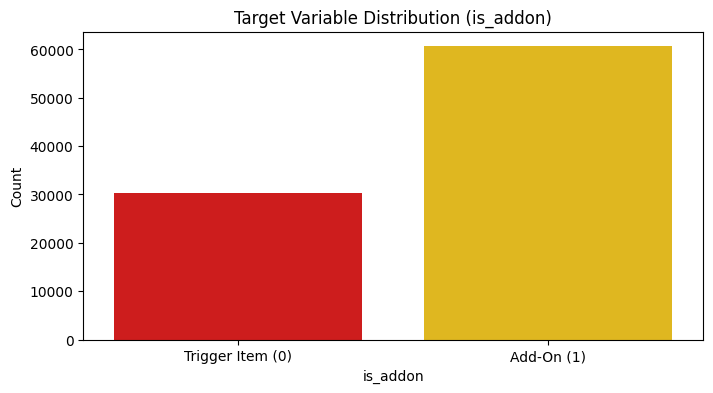

is_addon
1    60646
0    30400
Name: count, dtype: int64


In [20]:
# 0 = the item that triggered the order (first item)
# 1 = an add-on item added after the first item
plt.figure(figsize=(8, 4))
sns.countplot(x='is_addon', data=df, palette='hot')
plt.title('Target Variable Distribution (is_addon)')
plt.xticks([0, 1], ['Trigger Item (0)', 'Add-On (1)'])
plt.ylabel('Count')
plt.show()
print(df['is_addon'].value_counts())

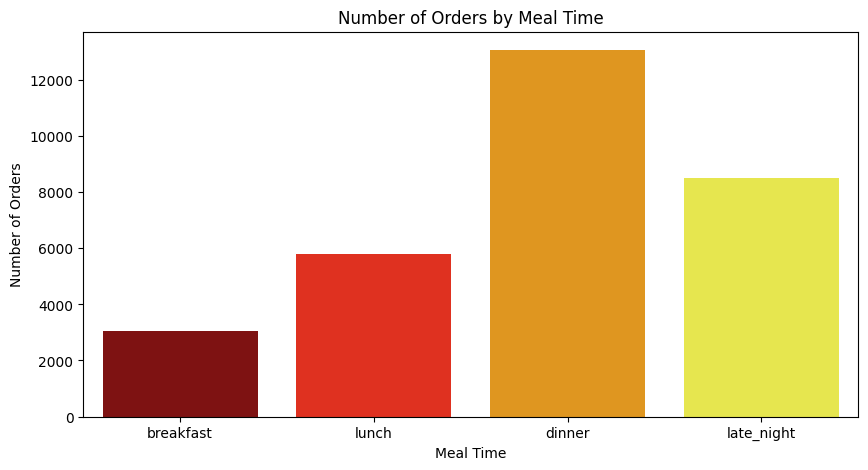

In [21]:
plt.figure(figsize=(10, 5))
meal_order = ['breakfast', 'lunch', 'dinner', 'late_night']
meal_counts = df.drop_duplicates('order_id')['meal_time'].value_counts().reindex(meal_order)
sns.barplot(x=meal_counts.index, y=meal_counts.values, palette='hot')
plt.title('Number of Orders by Meal Time')
plt.xlabel('Meal Time')
plt.ylabel('Number of Orders')
plt.show()

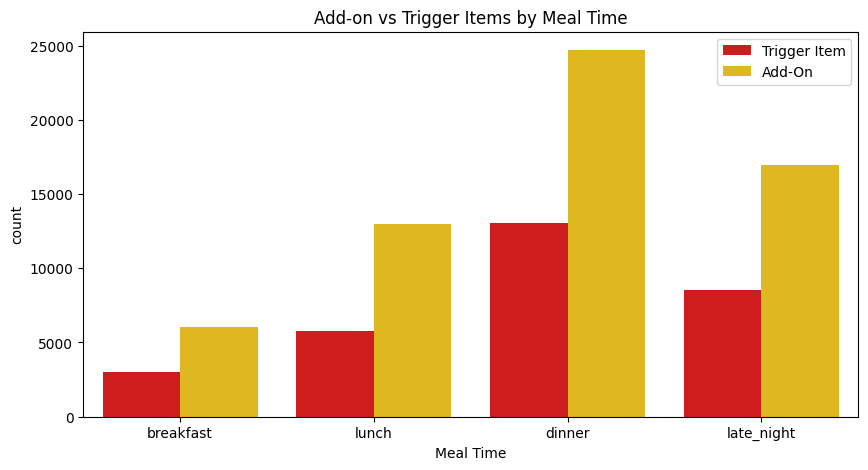

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(x='meal_time', hue='is_addon', data=df, palette='hot',
              order=meal_order)
plt.title('Add-on vs Trigger Items by Meal Time')
plt.xlabel('Meal Time')
plt.legend(['Trigger Item', 'Add-On'])
plt.show()

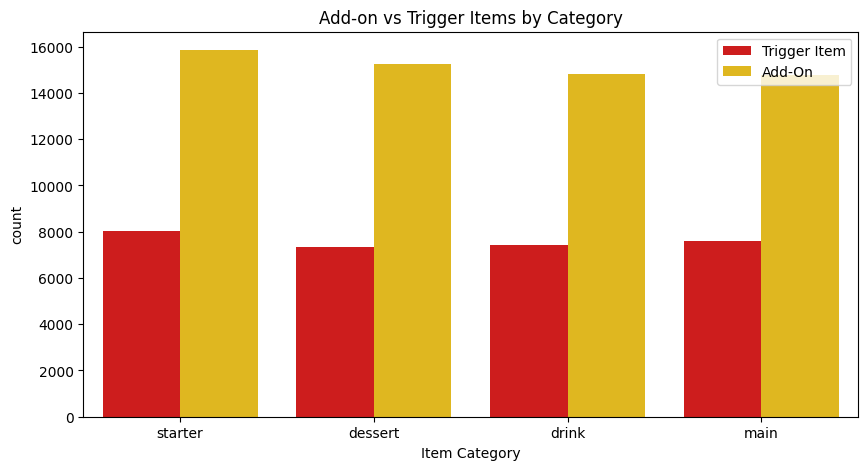

In [23]:
plt.figure(figsize=(10, 5))
sns.countplot(x='category', hue='is_addon', data=df, palette='hot')
plt.title('Add-on vs Trigger Items by Category')
plt.xlabel('Item Category')
plt.legend(['Trigger Item', 'Add-On'])
plt.show()

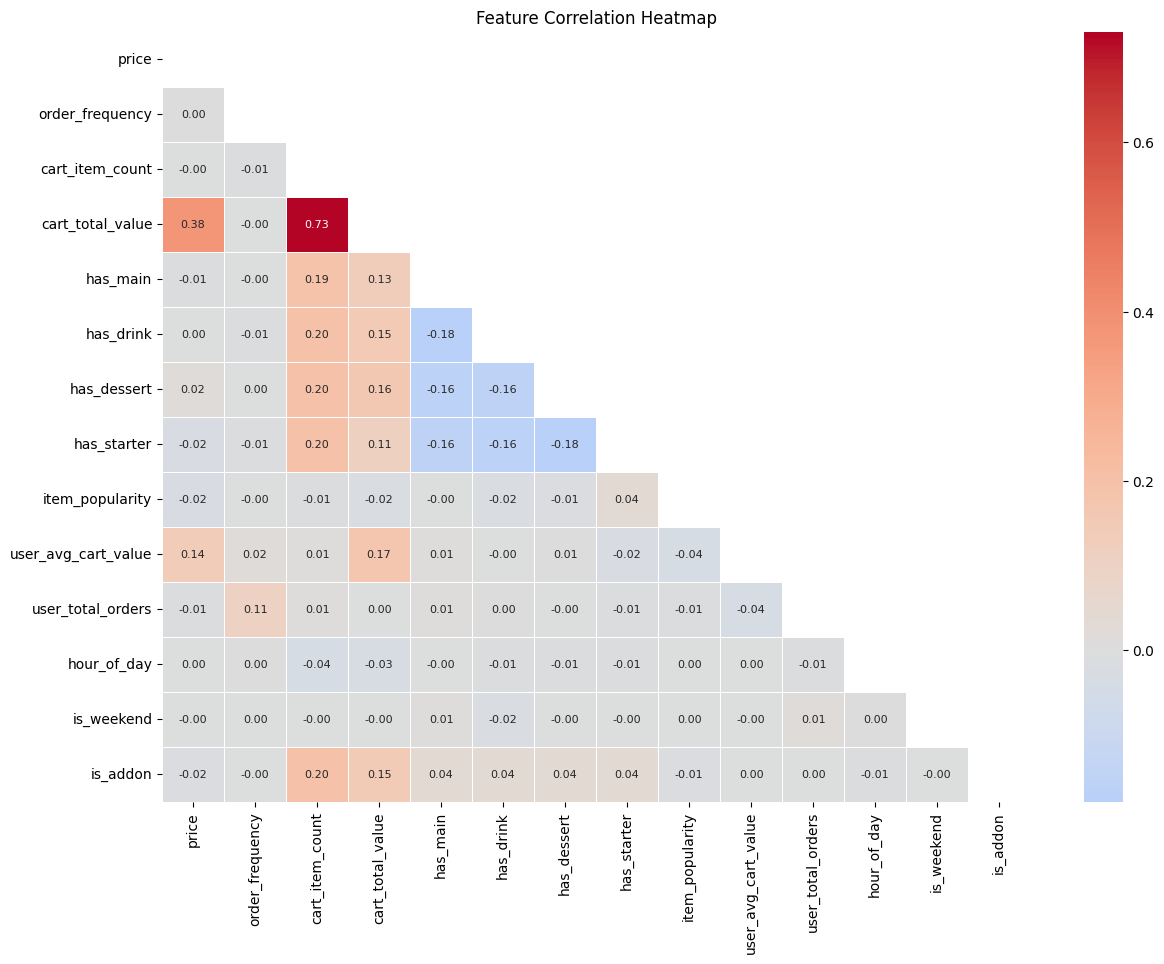

In [24]:

num_cols = ['price', 'order_frequency', 'cart_item_count', 'cart_total_value',
            'has_main', 'has_drink', 'has_dessert', 'has_starter',
            'item_popularity', 'user_avg_cart_value',
            'user_total_orders', 'hour_of_day', 'is_weekend', 'is_addon']

plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle (it's a mirror)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap')
plt.show()

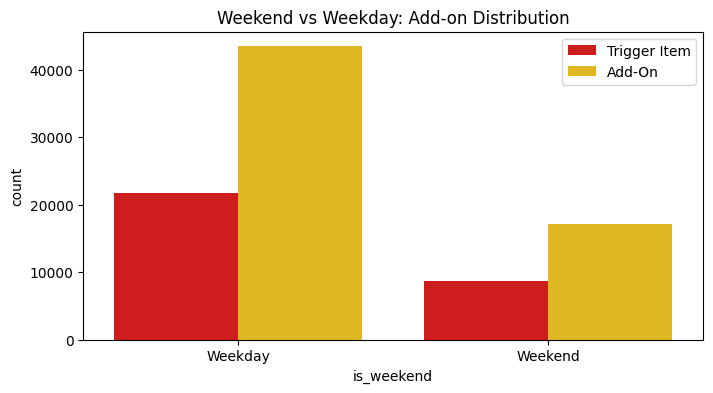

In [25]:
# Weekend vs weekday add-on behavior
plt.figure(figsize=(8, 4))
sns.countplot(x='is_weekend', hue='is_addon', data=df, palette='hot')
plt.title('Weekend vs Weekday: Add-on Distribution')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.legend(['Trigger Item', 'Add-On'])
plt.show()

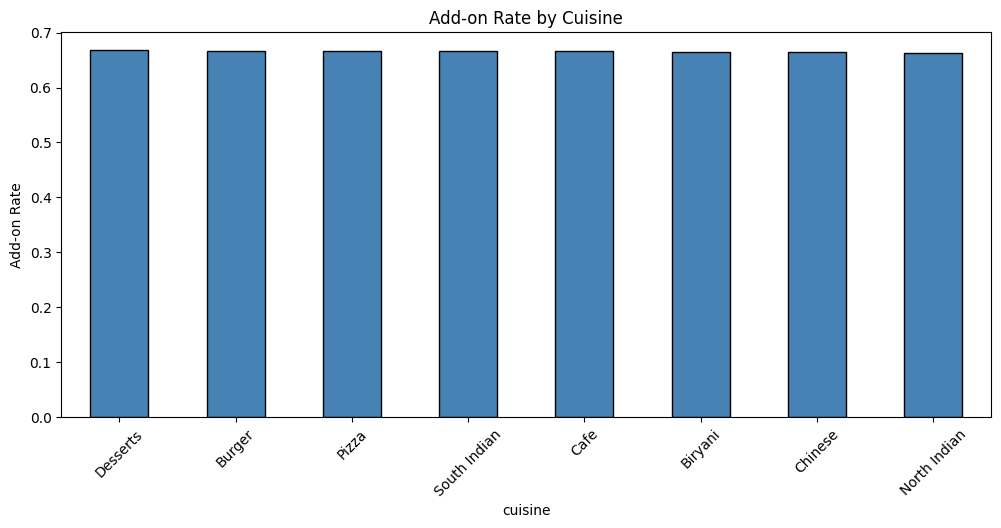

In [26]:
# Group data to see add-on rate per cuisine
df.groupby('cuisine')['is_addon'].mean().sort_values(ascending=False).plot(
    kind='bar', figsize=(12, 5), color='steelblue', edgecolor='black')
plt.title('Add-on Rate by Cuisine')
plt.ylabel('Add-on Rate')
plt.xticks(rotation=45)
plt.show()

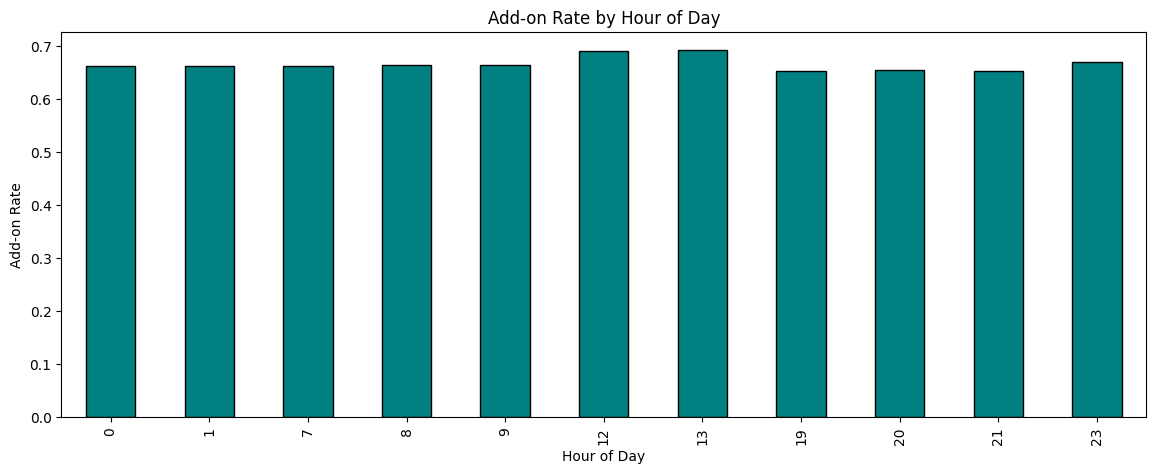

In [27]:
plt.figure(figsize=(14, 5))
df.groupby('hour_of_day')['is_addon'].mean().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Add-on Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Add-on Rate')
plt.show()

In [28]:
df_model = df.copy()
print('Working copy created. Shape:', df_model.shape)

Working copy created. Shape: (91046, 31)


In [29]:
df_model['price_vs_user_avg'] = df_model['price'] / (df_model['user_avg_cart_value'] + 1)
df_model['price_vs_user_avg'].describe()

count    91046.000000
mean         0.997162
std          0.404576
min          0.236840
25%          0.652450
50%          1.001749
75%          1.341828
max          2.021065
Name: price_vs_user_avg, dtype: float64

In [30]:
df_model['price_vs_cart_avg'] = np.where(
    df_model['user_avg_cart_value'] > 1,
    df_model['price'] / (df_model['cart_total_value'] / (df_model['user_avg_cart_value'] - 1) + 1),
    1.0  # For the first item there is no cart average yet
)
df_model['price_vs_cart_avg'].describe()

count    91046.000000
mean        85.710459
std         35.194747
min         15.825101
25%         58.721822
50%         83.710628
75%        108.402590
max        220.660103
Name: price_vs_cart_avg, dtype: float64

In [31]:

df_model['is_drink_or_dessert'] = df_model['category'].isin(['drink', 'dessert']).astype(int)
print('Drink or Dessert count:')
print(df_model['is_drink_or_dessert'].value_counts())

Drink or Dessert count:
is_drink_or_dessert
0    46249
1    44797
Name: count, dtype: int64


In [32]:
from sklearn.preprocessing import LabelEncoder

# These are the exact string columns in the dataset that need encoding
cat_encode_cols = [
    'city',
    'budget_type',
    'cuisine',
    'price_range',
    'category',
    'meal_time',
    'user_favorite_cuisine',
    'user_favorite_category',
    'price_sensitivity'        # this was the last bug — was string, now encoded
]

le = LabelEncoder()
for col in cat_encode_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    print(f'Encoded: {col} -> {col}_enc  | unique values: {df_model[col].nunique()}')

Encoded: city -> city_enc  | unique values: 7
Encoded: budget_type -> budget_type_enc  | unique values: 3
Encoded: cuisine -> cuisine_enc  | unique values: 8
Encoded: price_range -> price_range_enc  | unique values: 3
Encoded: category -> category_enc  | unique values: 4
Encoded: meal_time -> meal_time_enc  | unique values: 4
Encoded: user_favorite_cuisine -> user_favorite_cuisine_enc  | unique values: 8
Encoded: user_favorite_category -> user_favorite_category_enc  | unique values: 4
Encoded: price_sensitivity -> price_sensitivity_enc  | unique values: 3


In [33]:
FEATURES = [
    # --- Item level features ---
    'price',                      # int   - item price (numeric, use directly)
    'category_enc',               # int   - encoded from 'category' (main/drink/dessert/starter)
    'item_popularity',            # int   - how popular this item is (numeric, use directly)
    'is_drink_or_dessert',        # int   - drink or dessert flag (derived)

    # --- Cart context features ---
    'cart_total_value',           # int   - total cart value so far (numeric, use directly)
    'cart_item_count',            # int   - number of items already in cart (numeric, use directly)
    'cart_avg_price',             # float - average price of items in cart (numeric, use directly)
    'has_main',                   # int   - does cart have a main dish? (numeric, use directly)
    'has_drink',                  # int   - does cart have a drink? (numeric, use directly)
    'has_dessert',                # int   - does cart have a dessert? (numeric, use directly)
    'has_starter',                # int   - does cart have a starter? (numeric, use directly)
    'meal_completeness_score',    # int   - how complete is the meal (numeric, use directly)

    # --- User behavior features ---
    'budget_type_enc',            # int   - encoded from 'budget_type' (low/mid/premium)
    'order_frequency',            # int   - how often user orders (numeric, use directly)
    'user_avg_cart_value',        # float - user avg spending per order (numeric, use directly)
    'user_total_orders',          # int   - total historical orders (numeric, use directly)
    'user_favorite_cuisine_enc',  # int   - encoded from 'user_favorite_cuisine'
    'user_favorite_category_enc', # int   - encoded from 'user_favorite_category'

    # --- Contextual features ---
    'meal_time_enc',              # int   - encoded from 'meal_time' (breakfast/lunch/dinner/late_night)
    'hour_of_day',                # int   - exact hour (numeric, use directly)
    'day_of_week',                # int   - monday=0, sunday=6 (numeric, use directly)
    'is_weekend',                 # int   - weekend flag (numeric, use directly)
    'city_enc',                   # int   - encoded from 'city'
    'cuisine_enc',                # int   - encoded from 'cuisine'
    'price_range_enc',            # int   - encoded from 'price_range'
    'price_sensitivity_enc',      # int   - encoded from 'price_sensitivity' (low/medium/high)

    # --- Derived ratio features ---
    'price_vs_user_avg',          # float - derived above
    'price_vs_cart_avg',          # float - derived above
]

TARGET = 'is_addon'

print(f'Total features: {len(FEATURES)}')
print('Target        :', TARGET)

# Safety check — MUST print empty list [] before training
# If any column name appears here, it means it is still a string — go fix it
bad_cols = df_model[FEATURES].select_dtypes(include='object').columns.tolist()
if bad_cols:
    print(f'WARNING - still string columns: {bad_cols}')
else:
    print('All feature columns are numeric - safe to train!')

Total features: 28
Target        : is_addon
All feature columns are numeric - safe to train!


In [34]:
df_model[FEATURES + [TARGET]].head(10)

,price,category_enc,item_popularity,is_drink_or_dessert,cart_total_value,cart_item_count,cart_avg_price,has_main,has_drink,has_dessert,has_starter,meal_completeness_score,budget_type_enc,order_frequency,user_avg_cart_value,user_total_orders,user_favorite_cuisine_enc,user_favorite_category_enc,meal_time_enc,hour_of_day,day_of_week,is_weekend,city_enc,cuisine_enc,price_range_enc,price_sensitivity_enc,price_vs_user_avg,price_vs_cart_avg,is_addon
0,406,3,45,0,804,2,402.000000,0,0,0,1,1,2,19,343.788462,19,4,3,2,1,5,1,0,1,2,1,1.177534,121.358141,0
1,398,3,41,0,804,2,402.000000,0,0,0,1,1,2,19,343.788462,19,4,3,2,1,5,1,0,1,2,1,1.154331,118.966847,1
2,147,0,40,1,706,2,353.000000,0,1,1,0,2,1,11,352.250000,25,7,0,2,1,6,1,5,1,2,2,0.416136,48.837787,0
3,559,1,35,1,706,2,353.000000,0,1,1,0,2,1,11,352.250000,25,7,0,2,1,6,1,5,1,2,2,1.582449,185.716481,1
4,184,1,39,1,986,3,328.666667,1,1,1,0,3,0,28,351.747253,28,7,0,1,19,0,0,2,5,2,0,0.521620,48.279504,0
5,332,2,40,0,986,3,328.666667,1,1,1,0,3,0,28,351.747253,28,7,0,1,19,0,0,2,5,2,0,0.941184,87.113018,1
6,470,0,51,1,986,3,328.666667,1,1,1,0,3,0,28,351.747253,28,7,0,1,19,0,0,2,5,2,0,1.332399,123.322646,1
7,584,1,55,1,797,2,398.500000,1,1,0,0,2,2,11,389.000000,18,3,2,1,19,2,0,1,3,2,1,1.497436,191.216878,0
8,213,2,40,0,797,2,398.500000,1,1,0,0,2,2,11,389.000000,18,3,2,1,19,2,0,1,3,2,1,0.546154,69.741772,1
9,502,2,30,0,1280,3,426.666667,1,1,0,0,2,0,2,351.258621,18,3,2,3,12,1,0,6,4,0,0,1.425089,107.853947,0


**Train / test split**

In [35]:
df_model['order_timestamp'] = pd.to_datetime(df_model['order_timestamp'])
df_model.sort_values('order_timestamp', inplace=True)
df_model.reset_index(drop=True, inplace=True)

print('Data sorted by timestamp.')
print(f'Earliest order: {df_model["order_timestamp"].min()}')
print(f'Latest order  : {df_model["order_timestamp"].max()}')


Data sorted by timestamp.
Earliest order: 2024-01-01 00:05:00
Latest order  : 2024-12-30 23:52:00


In [36]:
split_idx = int(len(df_model) * 0.80)

train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]

print(f'Train size: {len(train_df):,} rows')
print(f'Test  size: {len(test_df):,} rows')
print(f'Train period: {train_df["order_timestamp"].min().date()} -> {train_df["order_timestamp"].max().date()}')
print(f'Test  period: {test_df["order_timestamp"].min().date()}  -> {test_df["order_timestamp"].max().date()}')

Train size: 72,836 rows
Test  size: 18,210 rows
Train period: 2024-01-01 -> 2024-10-19
Test  period: 2024-10-19  -> 2024-12-30


In [37]:
X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

# Sanity check
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test  shape:', X_test.shape)
print('y_test  shape:', y_test.shape)

X_train shape: (72836, 28)
y_train shape: (72836,)
X_test  shape: (18210, 28)
y_test  shape: (18210,)


In [38]:
print('Train add-on rate:', round(y_train.mean() * 100, 2), '%')
print('Test  add-on rate:', round(y_test.mean() * 100, 2), '%')

Train add-on rate: 66.63 %
Test  add-on rate: 66.53 %


**LightGBM model training**

In [39]:
bad_cols = X_train.select_dtypes(include='object').columns.tolist()
if bad_cols:
    print(f'ERROR - fix these string columns first: {bad_cols}')
else:
    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_valid = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)
    print('LightGBM datasets created successfully!')

LightGBM datasets created successfully!


In [40]:
params = {
    'objective'        : 'binary',    # Binary classification: is_addon = 0 or 1
    'metric'           : 'auc',       # Optimize for AUC score
    'boosting_type'    : 'gbdt',      # Gradient boosting decision trees
    'num_leaves'       : 63,          # Max leaves per tree — controls complexity
    'learning_rate'    : 0.05,        # How fast the model learns
    'feature_fraction' : 0.8,         # Use 80% of features per tree
    'bagging_fraction' : 0.8,         # Use 80% of rows per tree
    'bagging_freq'     : 5,           # Apply bagging every 5 iterations
    'min_child_samples': 20,          # Minimum data in a leaf
    'reg_alpha'        : 0.1,         # L1 regularization
    'reg_lambda'       : 0.1,         # L2 regularization
    'verbose'          : -1,          # Suppress logs
    'random_state'     : 42           # Reproducibility
}

print('Parameters set!')
print(params)

Parameters set!
{'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt', 'num_leaves': 63, 'learning_rate': 0.05, 'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 5, 'min_child_samples': 20, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'verbose': -1, 'random_state': 42}


In [41]:
print('Training LightGBM model...')
print('-' * 50)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_valid],
    callbacks=callbacks
)

print('-' * 50)
print(f'Training done! Best iteration: {model.best_iteration}')

Training LightGBM model...
--------------------------------------------------
[100]	valid_0's auc: 0.806715
[200]	valid_0's auc: 0.851367
[300]	valid_0's auc: 0.866533
[400]	valid_0's auc: 0.874995
[500]	valid_0's auc: 0.880294
[600]	valid_0's auc: 0.884124
[700]	valid_0's auc: 0.887086
[800]	valid_0's auc: 0.888637
[900]	valid_0's auc: 0.889539
[1000]	valid_0's auc: 0.890465
--------------------------------------------------
Training done! Best iteration: 960


**Model Evaluation**

In [42]:
y_pred_proba = model.predict(X_test, num_iteration=model.best_iteration)

# Convert to binary: >= 0.5 = add-on (1), else trigger item (0)
y_pred = (y_pred_proba >= 0.5).astype(int)

print('Sample predictions:')
for i in range(8):
    print(f'  Actual: {y_test.iloc[i]}  | Probability: {y_pred_proba[i]:.3f}  | Predicted: {y_pred[i]}')

Sample predictions:
  Actual: 0  | Probability: 0.371  | Predicted: 0
  Actual: 1  | Probability: 0.931  | Predicted: 1
  Actual: 1  | Probability: 0.930  | Predicted: 1
  Actual: 1  | Probability: 0.942  | Predicted: 1
  Actual: 1  | Probability: 0.786  | Predicted: 1
  Actual: 0  | Probability: 0.521  | Predicted: 1
  Actual: 1  | Probability: 0.953  | Predicted: 1
  Actual: 1  | Probability: 0.660  | Predicted: 1


In [43]:
# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f'AUC-ROC Score: {auc_score:.4f}')

AUC-ROC Score: 0.8909


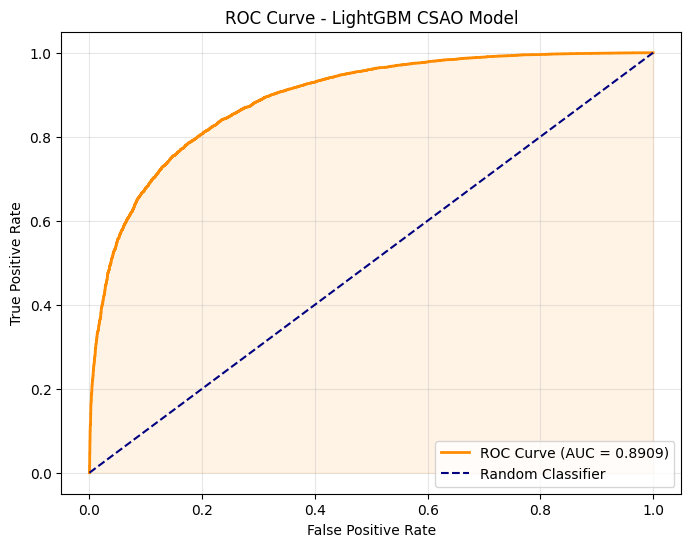

In [44]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM CSAO Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

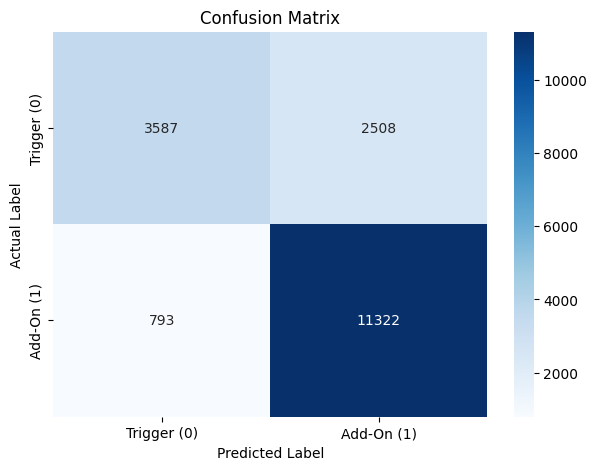

True Negatives  : 3,587
False Positives : 2,508
False Negatives : 793
True Positives  : 11,322


In [45]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pd.DataFrame(cm), annot=True, cmap='Blues', fmt='d',
            xticklabels=['Trigger (0)', 'Add-On (1)'],
            yticklabels=['Trigger (0)', 'Add-On (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  : {tn:,}')
print(f'False Positives : {fp:,}')
print(f'False Negatives : {fn:,}')
print(f'True Positives  : {tp:,}')

In [46]:
# Classification Report — Precision, Recall, F1 per class
print('=' * 55)
print('         CLASSIFICATION REPORT')
print('=' * 55)
print(classification_report(y_test, y_pred,
target_names=['Trigger Item (0)', 'Add-On (1)']))

         CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Trigger Item (0)       0.82      0.59      0.68      6095
      Add-On (1)       0.82      0.93      0.87     12115

        accuracy                           0.82     18210
       macro avg       0.82      0.76      0.78     18210
    weighted avg       0.82      0.82      0.81     18210



**Recall@K — Ranking Metric**

In [47]:
def recall_at_k(y_true_series, y_scores, test_data, k):
    eval_df = test_data.copy()
    eval_df['y_true']  = y_true_series.values
    eval_df['y_score'] = y_scores

    recalls = []
    for order_id, group in eval_df.groupby('order_id'):
        if group['y_true'].sum() == 0:
            continue
        group_sorted  = group.sort_values('y_score', ascending=False)
        top_k         = group_sorted.head(k)
        actual_addons = group['y_true'].sum()
        captured      = top_k['y_true'].sum()
        recalls.append(captured / actual_addons)

    return np.mean(recalls)

print('Recall@K function defined!')

Recall@K function defined!


In [48]:
k_values = [1, 3, 5, 8]
r_at_k   = [recall_at_k(y_test, y_pred_proba, test_df, k) for k in k_values]

print('=== RECALL@K RESULTS ===')
for k, r in zip(k_values, r_at_k):
    print(f'  Recall@{k} = {r:.4f}  ->  {r*100:.1f}% of add-ons captured in top-{k}')

=== RECALL@K RESULTS ===
  Recall@1 = 0.5691  ->  56.9% of add-ons captured in top-1
  Recall@3 = 0.9857  ->  98.6% of add-ons captured in top-3
  Recall@5 = 1.0000  ->  100.0% of add-ons captured in top-5
  Recall@8 = 1.0000  ->  100.0% of add-ons captured in top-8


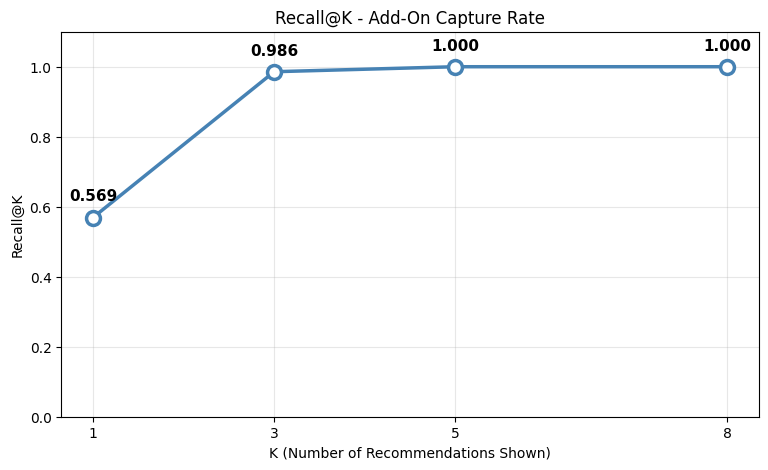

In [49]:
# Plot Recall@K
plt.figure(figsize=(9, 5))
plt.plot(k_values, r_at_k, marker='o', color='steelblue', linewidth=2.5,
         markersize=10, markerfacecolor='white', markeredgewidth=2.5)
for k, r in zip(k_values, r_at_k):
    plt.annotate(f'{r:.3f}', (k, r), textcoords='offset points',
                 xytext=(0, 12), ha='center', fontsize=11, fontweight='bold')
plt.xlabel('K (Number of Recommendations Shown)')
plt.ylabel('Recall@K')
plt.title('Recall@K - Add-On Capture Rate')
plt.xticks(k_values)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.show()

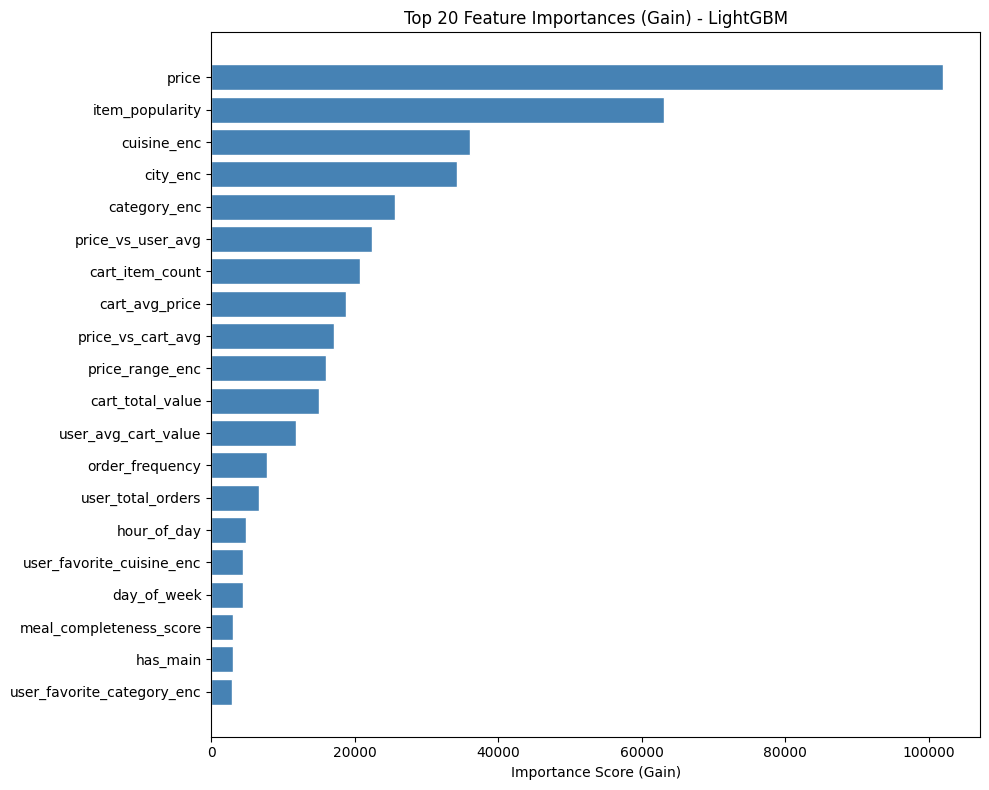

Top 10 Most Important Features:
          feature    importance
            price 102041.529874
  item_popularity  63030.858718
      cuisine_enc  36057.798092
         city_enc  34183.066176
     category_enc  25573.328604
price_vs_user_avg  22389.585609
  cart_item_count  20769.826218
   cart_avg_price  18742.125092
price_vs_cart_avg  17104.844762
  price_range_enc  15921.921427


In [50]:
# Feature Importance — which features mattered most?
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=True).tail(20)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='steelblue', edgecolor='white')
plt.title('Top 20 Feature Importances (Gain) - LightGBM')
plt.xlabel('Importance Score (Gain)')
plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print(importance_df.tail(10)[['feature','importance']].iloc[::-1].to_string(index=False))

In [51]:
# Final Evaluation Summary
print('=========================================')
print('     FINAL MODEL EVALUATION SUMMARY      ')
print('=========================================')
print(f'  AUC-ROC Score  : {auc_score:.4f}')
print(f'  Accuracy       : {accuracy_score(y_test, y_pred):.4f}')
print(f'  Precision      : {precision_score(y_test, y_pred):.4f}')
print(f'  Recall         : {recall_score(y_test, y_pred):.4f}')
print(f'  F1 Score       : {f1_score(y_test, y_pred):.4f}')
print('-----------------------------------------')
for k, r in zip(k_values, r_at_k):
    print(f'  Recall@{k}       : {r:.4f}  ({r*100:.1f}%)')
print('=========================================')

     FINAL MODEL EVALUATION SUMMARY      
  AUC-ROC Score  : 0.8909
  Accuracy       : 0.8187
  Precision      : 0.8187
  Recall         : 0.9345
  F1 Score       : 0.8728
-----------------------------------------
  Recall@1       : 0.5691  (56.9%)
  Recall@3       : 0.9857  (98.6%)
  Recall@5       : 1.0000  (100.0%)
  Recall@8       : 1.0000  (100.0%)


In [52]:
# Save model and predictions
model.save_model('csao_lgbm_model.txt')
print('Model saved as csao_lgbm_model.txt')

output_df = test_df[['order_id', 'user_id', 'item_id', 'category',
                      'cuisine', 'price', 'meal_time', 'city', 'is_addon']].copy()
output_df['predicted_probability'] = y_pred_proba
output_df['predicted_label']       = y_pred
output_df['correct_prediction']    = (output_df['is_addon'] == output_df['predicted_label']).astype(int)
output_df.to_csv('csao_predictions.csv', index=False)
print('Predictions saved as csao_predictions.csv')
output_df.head(10)

Model saved as csao_lgbm_model.txt
Predictions saved as csao_predictions.csv


,order_id,user_id,item_id,category,cuisine,price,meal_time,city,is_addon,predicted_probability,predicted_label,correct_prediction
72836,order_18658,user_1203,item_372,starter,Chinese,521,dinner,Hyderabad,0,0.370977,0,1
72837,order_18658,user_1203,item_378,drink,Chinese,475,dinner,Hyderabad,1,0.931263,1,1
72838,order_18658,user_1203,item_382,dessert,Chinese,265,dinner,Hyderabad,1,0.929629,1,1
72839,order_27633,user_754,item_1138,dessert,Biryani,444,dinner,Mumbai,1,0.942096,1,1
72840,order_27633,user_754,item_1131,dessert,Biryani,183,dinner,Mumbai,1,0.786333,1,1
72841,order_27633,user_754,item_1129,starter,Biryani,176,dinner,Mumbai,0,0.521348,1,0
72842,order_27633,user_754,item_1136,dessert,Biryani,343,dinner,Mumbai,1,0.953342,1,1
72843,order_23825,user_612,item_2236,drink,Desserts,205,dinner,Hyderabad,1,0.660138,1,1
72844,order_23825,user_612,item_2235,dessert,Desserts,342,dinner,Hyderabad,1,0.718881,1,1
72845,order_23825,user_612,item_2232,main,Desserts,313,dinner,Hyderabad,0,0.261831,0,1
